In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving clean_tickets_8000.csv to clean_tickets_8000 (2).csv


In [ ]:
import pandas as pd

df = pd.read_csv("clean_tickets_8000.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (8000, 15)

Columns:
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Technical Glitch Impairing Brand Expansion,"Issue: The campaign experienced a malfunction,...",I am here to assist you in resolving the techn...,Incident,Product Support,medium,en,Technical,Glitch,Brand,Expansion,Software,Integration,Issue,Support
1,Acknowledgment of Data Breach Concern and Requ...,"Dear [Customer Name],\n\nI am writing to ackno...","Dear [Customer Name],\n\nI am writing to ackno...",Incident,Product Support,high,en,Security,Breach,Customer,Follow-Up,Documentation,Incident,Resolution,NaN
2,Trouble with Periodic Connection Problems on O...,Currently facing periodic connection problems ...,We will investigate the issue and can be conta...,Incident,Customer Service,low,en,Network,Performance,Disruption,IT,Tech Support,NaN,NaN,NaN
3,Concern Regarding Medical Information Security,We've identified a potential security breach i...,We are taking this issue very seriously and wi...,Problem,Sales and Pre-Sales,medium,en,Security,Breach,Medical,Investigation,Antivirus,Firewall,Log,Access
4,Integration of IBM SPSS Statistics 28 for Inve...,Which analytics tools can be integrated with I...,"Hello <name>, thank you for contacting us abou...",Request,Billing and Payments,medium,en,Technical,Product,Integration,Investment,Optimization,Analytics,IBM,SPSS


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Combine subject and body into one input text
df["text"] = (
    df["subject"].fillna("") + " " +
    df["body"].fillna("")
)

# Convert queue names into numeric labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["queue"])

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

print("\nNumber of classes:", len(label_encoder.classes_))

Classes:
0 -> Billing and Payments
1 -> Customer Service
2 -> General Inquiry
3 -> Human Resources
4 -> IT Support
5 -> Product Support
6 -> Returns and Exchanges
7 -> Sales and Pre-Sales
8 -> Service Outages and Maintenance
9 -> Technical Support

Number of classes: 10


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df[["text", "label"]],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (6400, 2)
Test: (1600, 2)


In [ ]:
!pip install -q transformers datasets accelerate
!pip uninstall -y torchvision

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving clean_tickets_8000.csv to clean_tickets_8000 (3).csv


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("clean_tickets_8000.csv")

# Prepare text
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")

# Encode queue labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["queue"])

# Train / Test split
train_df, test_df = train_test_split(
    df[["text", "label"]],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Classes:", len(label_encoder.classes_))

Train: (6400, 2)
Test: (1600, 2)
Classes: 10


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True),
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True),
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 6400
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1600
})


In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed!")

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Tokenization completed!


In [ ]:
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

print(train_dataset.column_names)
print(test_dataset.column_names)

['label', 'input_ids', 'token_type_ids', 'attention_mask']
['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
train_dataset.set_format("torch")
test_dataset.set_format("torch")

print("Train columns:", train_dataset.column_names)
print("Test columns:", test_dataset.column_names)

print("\nFirst example:")
print(train_dataset[0])

Train columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Test columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']

First example:
{'label': tensor(7), 'input_ids': tensor([  101,  5043,  1997,  2951, 17271,  4270,  1999,  2902,  2009,  6125,
         3728,  1010,  2045,  2001,  2019, 24641,  3229,  2000,  5776,  2966,
         2636,  2349,  2000,  2951, 17271,  4270,  1012,  1996,  3497,  4436,
         2024,  5410,  3036,  5761,  1998, 25963,  4007,  1012,  4084,  2579,
         2421,  2039, 16616,  3424, 23350,  4007,  1998,  9283,  1037,  2897,
        13594,  1010,  2021,  1996,  3314,  2145, 29486,  1012,  5375,  2003,
         2734,  2000, 10663,  1996,  3277,  1998,  4652,  2925, 12510,  2229,
         1012,   102,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,  

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=10
)

model.to("cuda")

print("Model loaded successfully!")
print("Device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!
Device: cuda:0


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_queue_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="epoch",
    report_to="none"
)

print("Training arguments ready!")

Training arguments ready!


In [ ]:
import numpy as np

from transformers import Trainer
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer ready!")

Trainer ready!


In [ ]:
train_result = trainer.train()

Step,Training Loss
50,2.066495
100,1.884206
150,1.810877
200,1.721815
250,1.780820
300,1.751111
350,1.677503
400,1.682739
450,1.620502
500,1.617489


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
results = trainer.evaluate()

print("DistilBERT Test Results")
print("------------------------")
print("Accuracy:", round(results["eval_accuracy"], 4))
print("Macro-F1:", round(results["eval_macro_f1"], 4))

Training Loss,Validation Loss,Step,Accuracy,Macro F1
1.517858,1.608886,1200,0.411250,0.275514


DistilBERT Test Results
------------------------
Accuracy: 0.4113
Macro-F1: 0.2755


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.76      0.69      0.72       175
               Customer Service       0.27      0.32      0.29       250
                General Inquiry       0.00      0.00      0.00        23
                Human Resources       0.86      0.21      0.34        28
                     IT Support       0.43      0.02      0.03       186
                Product Support       0.35      0.24      0.29       299
          Returns and Exchanges       1.00      0.03      0.05        78
            Sales and Pre-Sales       0.00      0.00      0.00        44
Service Outages and Maintenance       0.74      0.39      0.51        59
              Technical Support       0.39      0.77      0.52       458

                       accuracy                           0.41      1600
                      macro avg       0.48      0.27      0.28      1600
                   weighted avg       0.44      0

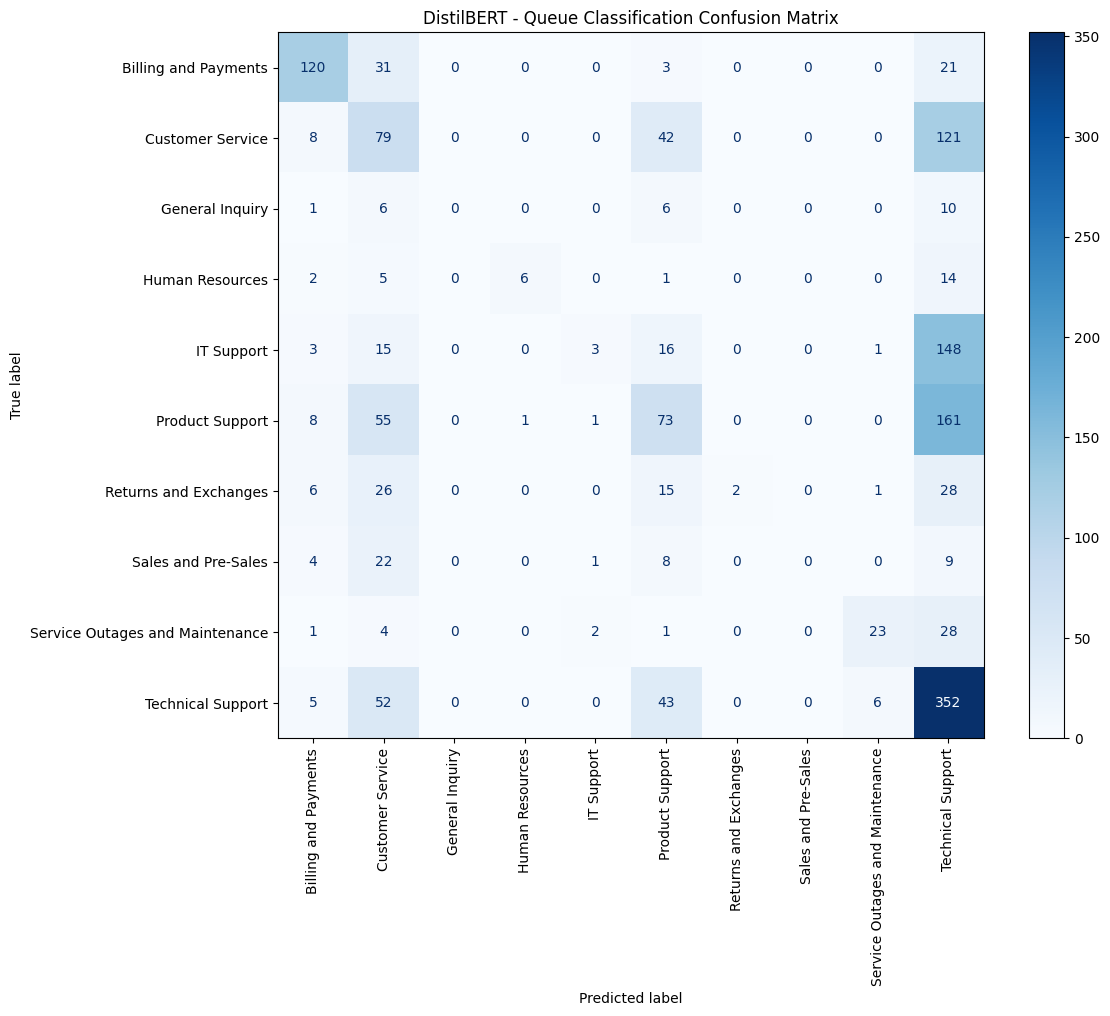

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("DistilBERT - Queue Classification Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
save_path = "./distilbert_queue_final"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model and tokenizer saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully!


In [ ]:
!zip -r distilbert_queue_final.zip distilbert_queue_final

  adding: distilbert_queue_final/ (stored 0%)
  adding: distilbert_queue_final/model.safetensors (deflated 8%)
  adding: distilbert_queue_final/config.json (deflated 58%)
  adding: distilbert_queue_final/training_args.bin (deflated 53%)
  adding: distilbert_queue_final/tokenizer.json (deflated 71%)
  adding: distilbert_queue_final/tokenizer_config.json (deflated 43%)


In [ ]:
from google.colab import files

files.download("distilbert_queue_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>